# Saving and Loading Models in PyTorch

#### Training a deep learning model takes time and resources. So, it is important to save the model after training so that it can be used later without retraining. 

`torch.save()` is a function that saves a model's weights, parameters, and
architecture to a file. The file can be loaded later using `torch.load_state_dict()` to
rebuild the model and use it for inference.

It is recommended to save only the state dictionary of the model instead of the entire model.

In [7]:
import numpy as np
import pandas as pd
import torch
import seaborn as sns

from geoai.utils_ml.dl_ops import DeepLearningOperations
from geoai.utils_ml.dl_ops import LinearRegressionTorch


dl_ops = DeepLearningOperations()

In [2]:
# data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
X = cars['wt']
y = cars['mpg']

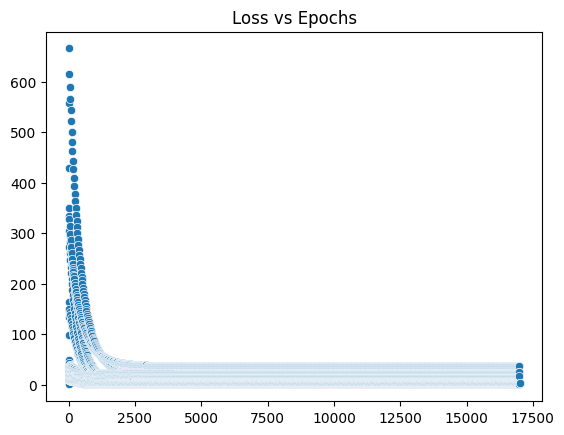

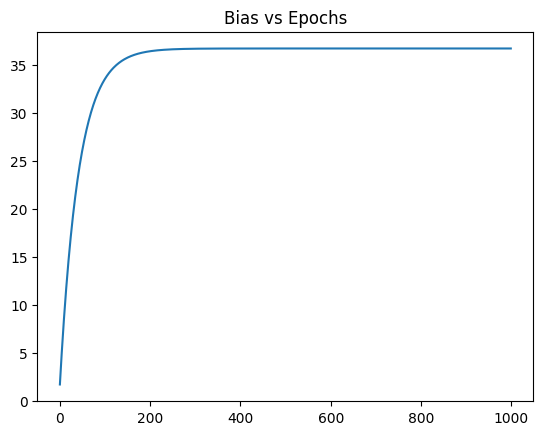

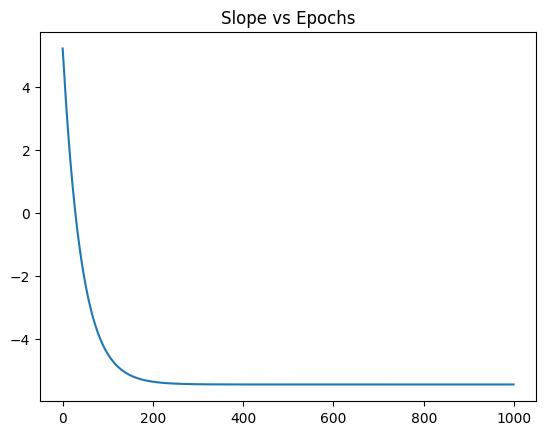

In [3]:
y_pred, bias, weights, model = dl_ops.lr_dataset_dataloaders(X, y, 0.01, 1000, batch_size=2)

In [4]:
model

LinearRegressionTorch(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [5]:
# Get the state dictionary of the model
model.state_dict()

OrderedDict([('linear.weight', tensor([[-5.4371]])),
             ('linear.bias', tensor([36.7174]))])

In [6]:
# Save the model
torch.save(model.state_dict(), 'trained_models/lr_pytorch.pth')

In [9]:
# Load the model
loaded_model = LinearRegressionTorch(input_size=1, output_size=1)
loaded_model.load_state_dict(torch.load('trained_models/lr_pytorch.pth'))
loaded_model.state_dict()

C:\Users\Reginald\AppData\Local\Temp\ipykernel_9448\1048269068.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('trained_models/lr

OrderedDict([('linear.weight', tensor([[-5.4371]])),
             ('linear.bias', tensor([36.7174]))])

In [12]:
# Lets assume that we have a new data
X_list_new = [1, 2, 3, 4, 5]
X_np_new = np.array(X_list_new, dtype=np.float32).reshape(-1,1)

# convert to tensors
X_new_tensor = torch.from_numpy(X_np_new)

In [13]:
# Reuse the model for prediction
loaded_model.eval() # set the model to evaluation mode
with torch.no_grad():
    predictions = loaded_model(X_new_tensor) # make predictions

predictions_np = predictions.numpy()

print("Predictions:", predictions_np)

Predictions: [[31.280304 ]
 [25.843224 ]
 [20.406141 ]
 [14.969061 ]
 [ 9.5319805]]
